
# 🏦 Bank Contact Centre LangGraph Multi-Agent System — Enhanced

This enhanced notebook upgrades the original bank contact centre notebook with:

- a **reusable JSON configuration file**
- **config-driven agent and collection setup**
- more reliable **tool wiring** for internal retrieval and DuckDuckGo web search
- safer **routing, retrieval, and debug logging**
- compatibility helpers for **Google Colab + Google Drive**

Use the companion config file:

`bank_contact_center_config.json`


In [1]:

# Optional: mount Google Drive when running in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Running outside Google Colab. Skipping drive mount.")


Mounted at /content/drive


In [2]:
# 1️⃣ INSTALL DEPENDENCIES
print("⏳ Installing dependencies...")
!pip install -qU \
    langchain-groq \
    langchain-huggingface \
    langchain-chroma \
    langchain-community \
    langgraph \
    sentence-transformers \
    unstructured \
    chromadb \
    gradio \
    pandas \
    duckduckgo-search \
    scikit-learn \
    matplotlib \
    joblib

!pip install -U ddgs

print("✅ Installation complete.")

⏳ Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 24.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.7/173.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 


## 2. Imports and configuration loader

This section:
1. imports the notebook dependencies,
2. loads the JSON config file,
3. creates any missing folders,
4. initializes the LLM and embeddings.


In [3]:


# 2️⃣ IMPORTS + CONFIG LOADER
import os
import json
import textwrap
from pathlib import Path
from typing import TypedDict, Dict, Any, List

import chromadb
import gradio as gr
import pandas as pd

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import DirectoryLoader, UnstructuredFileLoader
from langchain_community.tools.ddg_search.tool import DuckDuckGoSearchResults
from langgraph.graph import StateGraph, END

DEFAULT_CONFIG = {
    "paths": {
        "source_data_dir": "/content/drive/MyDrive/Colab Notebooks/bank_contact_centre_multi_agent/input_files",
        "db_path": "/content/drive/MyDrive/bank_contact_centre_chroma_db"
    },
    "models": {
        "embedding_model": "sentence-transformers/all-mpnet-base-v2",
        "groq_model": "openai/gpt-oss-120b",
        "temperature": 0.2
    },
    "retrieval": {
        "chunk_size": 1000,
        "chunk_overlap": 200,
        "top_k": 3
    },
    "web_search": {
        "enabled": True,
        "max_results": 5,
        "hints": [
            "today", "latest", "recent", "currently", "current", "now", "news",
            "public announcement", "mas", "monetary authority of singapore",
            "outage", "downtime", "maintenance", "network issue", "visa", "mastercard",
            "paynow", "giro", "fast", "scam alert", "police advisory", "interest rate",
            "exchange rate", "website", "public policy", "press release"
        ]
    },
    "agents": {
        "cards_fraud_agent": {
            "collection_name": "cards_fraud_collection",
            "persona": "Cards & Fraud Specialist",
            "description": "Lost cards, card fraud, scams, OTP compromise, unauthorised transactions, card blocking and urgent containment."
        },
        "payments_agent": {
            "collection_name": "payments_collection",
            "persona": "Payments and Transfers Specialist",
            "description": "FAST, GIRO, PayNow, remittance, transfer delays, payment tracing, and payment recovery."
        },
        "complaints_agent": {
            "collection_name": "complaints_collection",
            "persona": "Complaints and Service Recovery Specialist",
            "description": "Complaints, service recovery, branch dissatisfaction, rude service, escalation handling."
        },
        "service_agent": {
            "collection_name": "service_collection",
            "persona": "Bank Products and Account Servicing Specialist",
            "description": "Accounts, cards, loans, deposits, fees, account servicing, and general banking product questions."
        },
        "general_agent": {
            "collection_name": "general_collection",
            "persona": "General Banking Assistant",
            "description": "Fallback for greetings, broad questions, and topics outside the supported bank contact centre domains."
        }
    },
    "classification_rules": {
        "cards_fraud_agent": ["card", "fraud", "scam", "otp", "phishing", "stolen", "unauthorised", "chargeback"],
        "payments_agent": ["payment", "transfer", "fast", "giro", "paynow", "remittance", "beneficiary", "swift"],
        "complaints_agent": ["complaint", "escalation", "service recovery", "rude", "dissatisfaction", "feedback"],
        "service_agent": ["account", "loan", "deposit", "fixed deposit", "mortgage", "balance", "statement", "product", "servicing"]
    }
}

CONFIG_PATH = "/content/drive/MyDrive/bank_contact_center_config.json" if IN_COLAB else "bank_contact_center_config.json"

def ensure_config_file(config_path: str, default_config: Dict[str, Any]) -> None:
    if not os.path.exists(config_path):
        with open(config_path, "w", encoding="utf-8") as f:
            json.dump(default_config, f, indent=2)
        print(f"📝 Created default config file at: {config_path}")

def load_json_config(config_path: str) -> Dict[str, Any]:
    with open(config_path, "r", encoding="utf-8") as f:
        return json.load(f)

ensure_config_file(CONFIG_PATH, DEFAULT_CONFIG)
cfg = load_json_config(CONFIG_PATH)

SOURCE_DATA_DIR = cfg["paths"]["source_data_dir"]
DRIVE_DB_PATH = cfg["paths"]["db_path"]
EMBEDDING_MODEL = cfg["models"]["embedding_model"]
GROQ_MODEL = cfg["models"]["groq_model"]
GROQ_TEMPERATURE = cfg["models"].get("temperature", 0.2)
TOP_K = int(cfg["retrieval"].get("top_k", 3))

Path(SOURCE_DATA_DIR).mkdir(parents=True, exist_ok=True)
Path(DRIVE_DB_PATH).mkdir(parents=True, exist_ok=True)

try:
    from google.colab import userdata
    groq_key = userdata.get("GROQ_API_KEY")
    if groq_key:
        os.environ["GROQ_API_KEY"] = groq_key
except Exception:
    pass

if not os.environ.get("GROQ_API_KEY"):
    print("⚠️ GROQ_API_KEY is not set yet. Add it to Colab Secrets or os.environ before running the agent cells.")

llm = ChatGroq(model=GROQ_MODEL, temperature=GROQ_TEMPERATURE)
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)
persistent_client = chromadb.PersistentClient(path=DRIVE_DB_PATH)
splitter = RecursiveCharacterTextSplitter(
    chunk_size=int(cfg["retrieval"].get("chunk_size", 1000)),
    chunk_overlap=int(cfg["retrieval"].get("chunk_overlap", 200))
)
ddg_search_results = DuckDuckGoSearchResults(
    output_format="list",
    max_results=int(cfg["web_search"].get("max_results", 5))
)

print("✅ Environment ready.")
print("CONFIG_PATH      =", CONFIG_PATH)
print("SOURCE_DATA_DIR  =", SOURCE_DATA_DIR)
print("DRIVE_DB_PATH    =", DRIVE_DB_PATH)
print("GROQ_MODEL       =", GROQ_MODEL)
print("EMBEDDING_MODEL  =", EMBEDDING_MODEL)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Environment ready.
CONFIG_PATH      = /content/drive/MyDrive/bank_contact_center_config.json
SOURCE_DATA_DIR  = /content/drive/MyDrive/Colab Notebooks/bank_contact_centre_multi_agent/input_files
DRIVE_DB_PATH    = /content/drive/MyDrive/bank_contact_centre_chroma_db
GROQ_MODEL       = openai/gpt-oss-120b
EMBEDDING_MODEL  = sentence-transformers/all-mpnet-base-v2



## 3. Config preview

Review the active configuration before ingestion.  
You can edit the JSON file outside the notebook, then rerun this cell.


In [4]:

# 3️⃣ SHOW ACTIVE CONFIG
print(json.dumps(cfg, indent=2))


{
  "paths": {
    "source_data_dir": "/content/drive/MyDrive/Colab Notebooks/bank_contact_centre_multi_agent/input_files",
    "db_path": "/content/drive/MyDrive/bank_contact_centre_chroma_db"
  },
  "models": {
    "embedding_model": "sentence-transformers/all-mpnet-base-v2",
    "groq_model": "openai/gpt-oss-120b",
    "temperature": 0.2
  },
  "retrieval": {
    "chunk_size": 1000,
    "chunk_overlap": 200,
    "top_k": 3
  },
  "web_search": {
    "enabled": true,
    "max_results": 5,
    "hints": [
      "today",
      "latest",
      "recent",
      "currently",
      "current",
      "now",
      "news",
      "public announcement",
      "mas",
      "monetary authority of singapore",
      "outage",
      "downtime",
      "maintenance",
      "network issue",
      "visa",
      "mastercard",
      "paynow",
      "giro",
      "fast",
      "scam alert",
      "police advisory",
      "interest rate",
      "exchange rate",
      "website",
      "public policy",
      "pr


## 4. Ingestion engine

This section:
- classifies documents into specialist collections,
- stores chunks in Chroma,
- preserves source-file metadata for grounded answers.


In [5]:

# 4️⃣ BUILD KNOWLEDGE BASE

AGENT_ORDER = ["cards_fraud_agent", "payments_agent", "complaints_agent", "service_agent", "general_agent"]

def classify_collection(filename: str) -> str:
    fname = filename.lower()
    rules = cfg.get("classification_rules", {})
    agents_cfg = cfg.get("agents", {})

    for agent_name in AGENT_ORDER:
        keywords = rules.get(agent_name, [])
        if any(keyword.lower() in fname for keyword in keywords):
            return agents_cfg[agent_name]["collection_name"]

    return agents_cfg["general_agent"]["collection_name"]

def reset_selected_collections():
    target_collections = [cfg["agents"][agent]["collection_name"] for agent in cfg["agents"]]
    for collection_name in target_collections:
        try:
            persistent_client.delete_collection(collection_name)
            print(f"🗑️ Deleted old collection: {collection_name}")
        except Exception:
            pass

def load_documents_from_folder(folder_path: str):
    loader = DirectoryLoader(
        folder_path,
        glob="**/*",
        loader_cls=UnstructuredFileLoader,
        show_progress=True,
        use_multithreading=False
    )
    return loader.load()

def build_knowledge_base():
    if not os.path.exists(SOURCE_DATA_DIR):
        print(f"❌ Folder not found: {SOURCE_DATA_DIR}")
        return

    reset_selected_collections()

    docs = load_documents_from_folder(SOURCE_DATA_DIR)
    if not docs:
        print("⚠️ No documents found in the configured source folder.")
        return

    bucketed_docs = {
        cfg["agents"][agent]["collection_name"]: []
        for agent in cfg["agents"]
    }

    for doc in docs:
        source = doc.metadata.get("source", "unknown.txt")
        filename = os.path.basename(source)
        collection_name = classify_collection(filename)

        chunks = splitter.split_documents([doc])
        for chunk in chunks:
            chunk.metadata["source_file"] = filename
            chunk.metadata["collection_name"] = collection_name

        bucketed_docs[collection_name].extend(chunks)

    for collection_name, chunk_list in bucketed_docs.items():
        if not chunk_list:
            print(f"ℹ️ Skipping empty collection: {collection_name}")
            continue

        _ = Chroma.from_documents(
            documents=chunk_list,
            embedding=embeddings,
            client=persistent_client,
            collection_name=collection_name
        )
        print(f"✅ Stored {len(chunk_list)} chunks in {collection_name}")

    print("\n🎉 Knowledge base build complete.")

build_knowledge_base()


🗑️ Deleted old collection: cards_fraud_collection
🗑️ Deleted old collection: payments_collection
🗑️ Deleted old collection: complaints_collection
🗑️ Deleted old collection: service_collection
🗑️ Deleted old collection: general_collection


100%|██████████| 8/8 [00:15<00:00,  1.97s/it]


✅ Stored 2 chunks in cards_fraud_collection
✅ Stored 2 chunks in payments_collection
✅ Stored 7 chunks in complaints_collection
✅ Stored 3 chunks in service_collection
✅ Stored 21 chunks in general_collection

🎉 Knowledge base build complete.



## 5. Retrieval inspection

Use this to verify that a specific collection can return relevant chunks.


In [6]:

# 5️⃣ INSPECT RETRIEVAL
def inspect_collection(collection_name: str, query: str, k: int = 2):
    try:
        db = Chroma(
            client=persistent_client,
            collection_name=collection_name,
            embedding_function=embeddings
        )
        docs = db.similarity_search(query, k=k)
        print(f"\n🔎 Collection: {collection_name}")
        print(f"Query: {query}")
        print("-" * 80)
        for i, d in enumerate(docs, start=1):
            print(f"[{i}] Source: {d.metadata.get('source_file', 'unknown')}")
            print(d.page_content[:500])
            print("-" * 80)
    except Exception as e:
        print(f"⚠️ Could not inspect {collection_name}: {e}")

inspect_collection(cfg["agents"]["cards_fraud_agent"]["collection_name"], "customer says card was stolen and otp was shared")
inspect_collection(cfg["agents"]["payments_agent"]["collection_name"], "FAST transfer pending and beneficiary did not receive funds")
inspect_collection(cfg["agents"]["service_agent"]["collection_name"], "personal loan early repayment and fixed deposit placement")



🔎 Collection: cards_fraud_collection
Query: customer says card was stolen and otp was shared
--------------------------------------------------------------------------------
[1] Source: Fraud handling.txt
What do HSBC Singapore do when there is a bank fraud In the event of a bank fraud, HSBC Singapore takes several proactive steps to protect customers' funds and personal information. Here are the key actions they take: Immediate Contact: HSBC Singapore contacts the customer to confirm the fraud and provide instructions on how to react. Account Lockdown: The bank locks the customer's account to prevent further unauthorized transactions. Transaction Monitoring: The bank monitors the customer's acco
--------------------------------------------------------------------------------
[2] Source: Fraud handling.txt
These measures are part of HSBC Singapore's commitment to safeguarding customers' financial information and preventing fraud. Customers are encouraged to stay informed and vigilant 


## 6. Tool layer

Each specialist gets:
- an **internal retrieval tool** bound to its collection,
- a **DuckDuckGo web tool** for public and current external information.


In [7]:

# 6️⃣ BUILD TOOLS

WEB_SEARCH_HINTS = [hint.lower() for hint in cfg.get("web_search", {}).get("hints", [])]
WEB_SEARCH_ENABLED = bool(cfg.get("web_search", {}).get("enabled", True))

def should_use_web_search(query: str) -> bool:
    q = query.lower()
    return WEB_SEARCH_ENABLED and any(hint in q for hint in WEB_SEARCH_HINTS)

def format_docs_for_answer(docs) -> str:
    if not docs:
        return "No internal documents found."
    formatted = []
    for i, d in enumerate(docs, start=1):
        src = d.metadata.get("source_file", "unknown")
        formatted.append(f"[{i}] Source: {src}\n{d.page_content}")
    return "\n\n".join(formatted)

def make_retrieval_tool(collection_name: str, tool_name: str, description: str):
    @tool(tool_name)
    def retrieval_tool(query: str) -> str:
        """Search the internal Chroma collection for grounded bank knowledge."""
        try:
            db = Chroma(
                client=persistent_client,
                collection_name=collection_name,
                embedding_function=embeddings
            )
            docs = db.similarity_search(query, k=TOP_K)
            return format_docs_for_answer(docs)
        except Exception as e:
            return f"Error retrieving documents from {collection_name}: {e}"

    retrieval_tool.description = description
    return retrieval_tool

@tool("duckduckgo_search")
def duckduckgo_search(query: str) -> str:
    """Search public web sources for current or external information."""
    if not should_use_web_search(query):
        return "Web search not required for this query. Use internal retrieval first."
    try:
        raw_results = ddg_search_results.invoke(query)

        if isinstance(raw_results, str):
            return raw_results

        if not raw_results:
            return "No web results found."

        lines = []
        for idx, item in enumerate(raw_results[: cfg["web_search"].get("max_results", 5)], start=1):
            title = item.get("title", "Untitled")
            snippet = item.get("snippet", "")
            link = item.get("link", "")
            lines.append(f"[{idx}] {title}\nSnippet: {snippet}\nLink: {link}")

        return "\n\n".join(lines)
    except Exception as e:
        return f"DuckDuckGo search error: {e}"

cards_fraud_rag_tool = make_retrieval_tool(
    cfg["agents"]["cards_fraud_agent"]["collection_name"],
    "cards_fraud_rag_search",
    "Use this to search internal cards, fraud, scam, OTP, and unauthorised transaction documents."
)
payments_rag_tool = make_retrieval_tool(
    cfg["agents"]["payments_agent"]["collection_name"],
    "payments_rag_search",
    "Use this to search internal FAST, GIRO, PayNow, remittance, transfer, and payment operations documents."
)
complaints_rag_tool = make_retrieval_tool(
    cfg["agents"]["complaints_agent"]["collection_name"],
    "complaints_rag_search",
    "Use this to search internal complaints, escalation, customer dissatisfaction, and service recovery documents."
)
service_rag_tool = make_retrieval_tool(
    cfg["agents"]["service_agent"]["collection_name"],
    "service_rag_search",
    "Use this to search internal account servicing, deposits, loans, fees, and product servicing documents."
)
general_rag_tool = make_retrieval_tool(
    cfg["agents"]["general_agent"]["collection_name"],
    "general_rag_search",
    "Use this to search the fallback internal collection when no specialist collection is suitable."
)

print("✅ Tools ready.")


✅ Tools ready.



## 7. Router node

The router does classification only.  
It decides which specialist should answer the query.


In [8]:

# 7️⃣ ROUTER NODE
VALID_ROUTES = list(cfg["agents"].keys())

def build_router_prompt() -> str:
    bullet_lines = []
    for agent_name, agent_cfg in cfg["agents"].items():
        bullet_lines.append(f"- {agent_name} = {agent_cfg['description']}")
    return (
        "You are a bank contact centre routing classifier.\n\n"
        "Classify the user query into exactly one of these labels:\n"
        + "\n".join(bullet_lines)
        + "\n\nReturn ONLY one label from:\n"
        + "\n".join(VALID_ROUTES)
        + "\n\nIf unsure, return service_agent."
    )

ROUTER_PROMPT = build_router_prompt()

def router_node(state):
    query = state["query"]
    try:
        response = llm.invoke([
            SystemMessage(content=ROUTER_PROMPT),
            HumanMessage(content=query)
        ])
        decision = response.content.strip().lower().replace('"', "").replace("'", "").strip(".")
    except Exception:
        decision = "service_agent"

    if decision not in VALID_ROUTES:
        decision = "service_agent"

    return {
        "next_node": decision,
        "debug_log": f"🚦 Router selected: {decision}"
    }

test_queries = [
    "My credit card was stolen and I gave the OTP to someone.",
    "My FAST transfer is still pending.",
    "I want to complain about rude service from the branch.",
    "Can I repay my personal loan early?",
    "Tell me a joke."
]

print(f"{'QUERY':<60} | {'DECISION':<22}")
print("-" * 90)
for q in test_queries:
    res = router_node({"query": q})
    print(f"{q[:60]:<60} | {res['next_node']:<22}")


QUERY                                                        | DECISION              
------------------------------------------------------------------------------------------
My credit card was stolen and I gave the OTP to someone.     | cards_fraud_agent     
My FAST transfer is still pending.                           | payments_agent        
I want to complain about rude service from the branch.       | complaints_agent      
Can I repay my personal loan early?                          | service_agent         
Tell me a joke.                                              | general_agent         



## 8. Specialist agents

These nodes are config-driven and use:
- internal retrieval first,
- DuckDuckGo only for current/public external topics,
- grounded response instructions with debug traces.


In [9]:

# 8️⃣ SPECIALIST AGENT NODES

def retrieve_internal_context(collection_name: str, query: str, k: int = TOP_K):
    try:
        db = Chroma(
            client=persistent_client,
            collection_name=collection_name,
            embedding_function=embeddings
        )
        docs = db.similarity_search(query, k=k)
        return docs
    except Exception:
        return []

def run_grounded_agent(state, agent_name: str):
    query = state["query"]
    agent_cfg = cfg["agents"][agent_name]
    collection_name = agent_cfg["collection_name"]
    persona = agent_cfg["persona"]

    docs = retrieve_internal_context(collection_name, query, k=TOP_K)
    internal_context = format_docs_for_answer(docs) if docs else "No internal context found."

    use_web = should_use_web_search(query)
    external_context = duckduckgo_search.invoke(query) if use_web else "No external web context used."

    if internal_context.strip() == "No internal context found." and (not external_context or "No web results found." in external_context):
        return {
            "response": "I could not find that information in the approved internal knowledge base, and I also did not find useful public web results.",
            "debug_log": state.get("debug_log", "") + f" | {agent_name}: no internal context and no web results."
        }

    system_prompt = f"""
You are the {persona}.

Answering policy:
1. Prioritise INTERNAL CONTEXT for bank procedures, scripts, controls, and service actions.
2. Use EXTERNAL WEB CONTEXT only for public, current, or external information explicitly relevant to the user's question.
3. Do not invent policies, timelines, liabilities, fees, guarantees, or approval outcomes.
4. If internal policy is missing, say that clearly.
5. If web context is used, clearly label it as public web information.
6. Give practical next steps suitable for a bank contact centre.
7. Keep the answer concise, safe, and customer-friendly.

INTERNAL CONTEXT:
{internal_context}

EXTERNAL WEB CONTEXT:
{external_context}
"""

    response = llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=query)
    ])

    debug_bits = [
        state.get("debug_log", ""),
        f"{agent_name}: collection={collection_name}",
        f"{agent_name}: internal_chunks={len(docs)}",
        f"{agent_name}: web_search_used={use_web}"
    ]

    return {
        "response": response.content,
        "debug_log": " | ".join(bit for bit in debug_bits if bit)
    }

def cards_fraud_agent_node(state):
    return run_grounded_agent(state, "cards_fraud_agent")

def payments_agent_node(state):
    return run_grounded_agent(state, "payments_agent")

def complaints_agent_node(state):
    return run_grounded_agent(state, "complaints_agent")

def service_agent_node(state):
    return run_grounded_agent(state, "service_agent")

def general_agent_node(state):
    query = state["query"]
    if should_use_web_search(query):
        external_context = duckduckgo_search.invoke(query)
        prompt = f"""
You are a helpful general banking assistant.
Use the public web context below only when relevant.
If the topic is outside bank support, say that clearly.

PUBLIC WEB CONTEXT:
{external_context}
"""
        response = llm.invoke([
            SystemMessage(content=prompt),
            HumanMessage(content=query)
        ])
        return {
            "response": response.content,
            "debug_log": state.get("debug_log", "") + " | general_agent: answered with public web context."
        }

    return {
        "response": "I can help with bank contact centre topics such as cards, fraud, payments, complaints, accounts, deposits, and loans. For current public information, I can also use DuckDuckGo when needed.",
        "debug_log": state.get("debug_log", "") + " | general_agent: handled fallback request."
    }



## 9. LangGraph orchestration

Now we connect:
- router
- cards and fraud agent
- payments agent
- complaints agent
- service agent
- general agent
into one executable graph.


In [10]:

# 9️⃣ BUILD LANGGRAPH
class AgentState(TypedDict):
    query: str
    response: str
    next_node: str
    debug_log: str

workflow = StateGraph(AgentState)

workflow.add_node("router", router_node)
workflow.add_node("cards_fraud_agent", cards_fraud_agent_node)
workflow.add_node("payments_agent", payments_agent_node)
workflow.add_node("complaints_agent", complaints_agent_node)
workflow.add_node("service_agent", service_agent_node)
workflow.add_node("general_agent", general_agent_node)

workflow.set_entry_point("router")
workflow.add_conditional_edges("router", lambda state: state["next_node"])
workflow.add_edge("cards_fraud_agent", END)
workflow.add_edge("payments_agent", END)
workflow.add_edge("complaints_agent", END)
workflow.add_edge("service_agent", END)
workflow.add_edge("general_agent", END)

app = workflow.compile()
print("✅ LangGraph workflow compiled.")


✅ LangGraph workflow compiled.



## 10. Console testing

Test the full system before launching the UI.


In [11]:

# 🔟 TEST THE FULL SYSTEM
def test_agent(question: str):
    print(f"\n❓ {question}")
    result = app.invoke({
        "query": question,
        "response": "",
        "next_node": "",
        "debug_log": ""
    })
    print("🤖 Answer:\n", result["response"])
    print("\n🧠 Debug Log:\n", result["debug_log"])
    print("-" * 100)

test_agent("My debit card was stolen and I shared my OTP. What should I do?")
test_agent("My FAST transfer is pending for 45 minutes. What is the next step?")
test_agent("I want to complain about rude service from a branch officer.")
test_agent("Can I repay my personal loan early?")
test_agent("Are there any recent public scam alerts in Singapore related to card phishing today?")



❓ My debit card was stolen and I shared my OTP. What should I do?
🤖 Answer:
 **What to do right away**

1. **Call HSBC Singapore immediately** on the 24‑hour fraud helpline (or the number on the back of your card) and tell the agent that your debit card has been stolen and the OTP was shared.  
2. **Ask the agent to block/lock the card** and issue a replacement. This stops any further unauthorized transactions.  
3. **Confirm that the account is being locked** for any additional activity while the investigation starts.  

**What will happen next**

- HSBC will **verify the recent transactions** and monitor the account for any suspicious activity.  
- The bank will **report the incident to the police** and any relevant authorities.  
- You will receive **guidance on protecting your personal information** and steps to avoid future scams (e.g., never share OTPs, use secure channels).  

**What you can do meanwhile**

- Review your recent transaction history (online or via the app) and no

## 10A. Machine learning on the call-centre database

This section adds a supervised machine-learning workflow using the uploaded `Comprehensive_Banking_Database.csv` as structured input data.

**What this ML block does**
- Loads the call-centre / banking operations dataset
- Cleans mixed data types and converts date columns into model-friendly features
- Builds a preprocessing + modeling pipeline
- Trains an **anomaly classification** model using the `Anomaly` column as the target
- Evaluates performance with accuracy, precision, recall, F1, ROC-AUC, confusion matrix, and top feature importance
- Saves the fitted model so it can be reused later in the notebook or exported

> Note: ID fields and obvious personally identifiable information are excluded from training to reduce leakage and improve generalisation.


In [12]:
# 10A️⃣ MACHINE LEARNING PIPELINE — CALL-CENTRE DATABASE ANOMALY PREDICTION
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Flexible path detection for local runtime or Colab / Drive
candidate_paths = [
    Path("/mnt/data/Comprehensive_Banking_Database.csv"),
    Path("/content/Comprehensive_Banking_Database.csv"),
    Path("/content/drive/MyDrive/Comprehensive_Banking_Database.csv"),
]

CALL_CENTRE_DB_PATH = next((p for p in candidate_paths if p.exists()), None)

if CALL_CENTRE_DB_PATH is None:
    raise FileNotFoundError(
        "CSV database not found. Upload Comprehensive_Banking_Database.csv "
        "or update candidate_paths to the correct location."
    )

raw_df = pd.read_csv(CALL_CENTRE_DB_PATH)
print(f"✅ Loaded database from: {CALL_CENTRE_DB_PATH}")
print(f"✅ Database shape: {raw_df.shape}")
display(raw_df.head(3))

✅ Loaded database from: /content/drive/MyDrive/Comprehensive_Banking_Database.csv
✅ Database shape: (5000, 40)


,Customer ID,First Name,Last Name,Age,Gender,Address,City,Contact Number,Email,Account Type,...,Minimum Payment Due,Payment Due Date,Last Credit Card Payment Date,Rewards Points,Feedback ID,Feedback Date,Feedback Type,Resolution Status,Resolution Date,Anomaly
0,1,Joshua,Hall,45,Male,Address_1,Fort Worth,19458794854,joshua.hall@kag.com,Current,...,226.22,11/26/2023,3/20/2023,8142,1,10/6/2023,Suggestion,Resolved,1/22/2023,1
1,2,Mark,Taylor,47,Female,Address_2,Louisville,19458794855,mark.taylor@kag.com,Current,...,42.84,11/5/2023,6/16/2023,4306,2,4/7/2023,Complaint,Resolved,8/27/2023,1
2,3,Joseph,Flores,25,Female,Address_3,Philadelphia,19458794856,joseph.flores@kag.com,Current,...,162.12,1/8/2023,3/20/2023,4842,3,9/7/2023,Praise,Pending,5/11/2023,1


In [13]:

# 10A️⃣ STEP 2 — DATA PREPARATION
ml_df = raw_df.copy()

# Standardise target
TARGET_COL = "Anomaly"
if TARGET_COL not in ml_df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in dataset.")

ml_df[TARGET_COL] = pd.to_numeric(ml_df[TARGET_COL], errors="coerce")
ml_df = ml_df.dropna(subset=[TARGET_COL]).copy()

# Standardise anomaly labels to binary 0/1
ml_df[TARGET_COL] = ml_df[TARGET_COL].replace({-1: 0}).astype(int)

# Convert date columns to datetime and derive model-friendly components
date_cols = [
    "Date Of Account Opening",
    "Last Transaction Date",
    "Transaction Date",
    "Approval/Rejection Date",
    "Payment Due Date",
    "Last Credit Card Payment Date",
    "Feedback Date",
    "Resolution Date",
]

for col in date_cols:
    if col in ml_df.columns:
        ml_df[col] = pd.to_datetime(ml_df[col], errors="coerce")
        ml_df[f"{col}_year"] = ml_df[col].dt.year
        ml_df[f"{col}_month"] = ml_df[col].dt.month
        ml_df[f"{col}_day"] = ml_df[col].dt.day
        ml_df[f"{col}_weekday"] = ml_df[col].dt.weekday

# Optional duration-style feature
if {"Feedback Date", "Resolution Date"}.issubset(ml_df.columns):
    ml_df["Resolution Turnaround Days"] = (
        ml_df["Resolution Date"] - ml_df["Feedback Date"]
    ).dt.days

# Drop raw datetime columns after feature extraction
ml_df = ml_df.drop(columns=[c for c in date_cols if c in ml_df.columns], errors="ignore")

# Exclude identifiers and high-PII columns from training
drop_cols = [
    TARGET_COL,
    "Customer ID",
    "TransactionID",
    "Loan ID",
    "CardID",
    "Feedback ID",
    "First Name",
    "Last Name",
    "Address",
    "Contact Number",
    "Email",
]

X = ml_df.drop(columns=[c for c in drop_cols if c in ml_df.columns], errors="ignore")
y = ml_df[TARGET_COL]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Rows used for ML: {len(X):,}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Target balance:\n{y.value_counts(normalize=True).sort_index().rename('ratio')}")


Rows used for ML: 5,000
Numeric features: 45
Categorical features: 9
Target balance:
Anomaly
0    0.06
1    0.94
Name: ratio, dtype: float64


In [14]:

# 10A️⃣ STEP 3 — PREPROCESSING + TRAIN / TEST SPLIT
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

rf_pipeline.fit(X_train, y_train)
print("✅ RandomForest anomaly model trained.")


✅ RandomForest anomaly model trained.


📊 Evaluation metrics
  accuracy: 0.9400
 precision: 0.9400
    recall: 1.0000
        f1: 0.9691
   roc_auc: 0.4714

📄 Classification report
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        60
           1     0.9400    1.0000    0.9691       940

    accuracy                         0.9400      1000
   macro avg     0.4700    0.5000    0.4845      1000
weighted avg     0.8836    0.9400    0.9109      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


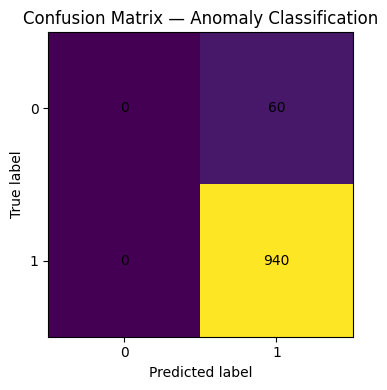

In [15]:

# 10A️⃣ STEP 4 — MODEL EVALUATION
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob),
}

print("📊 Evaluation metrics")
for k, v in metrics.items():
    print(f"{k:>10}: {v:.4f}")

print("\n📄 Classification report")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm)
ax.set_title("Confusion Matrix — Anomaly Classification")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["0", "1"])
ax.set_yticklabels(["0", "1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


,feature,importance
0,num__Account Balance,0.033104
1,num__Rewards Points,0.031934
2,num__Transaction Amount,0.031929
3,num__Account Balance After Transaction,0.031154
4,num__Loan Amount,0.030895
5,num__Interest Rate,0.030747
6,num__Resolution Turnaround Days,0.030617
7,num__Credit Card Balance,0.029757
8,num__Credit Limit,0.029757
9,num__Resolution Date_day,0.029453


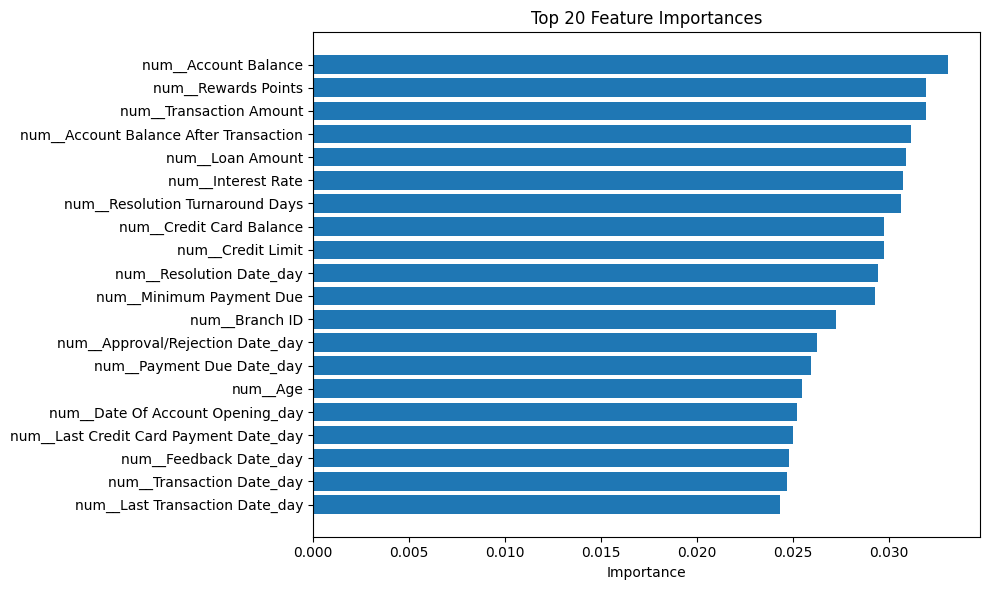

In [16]:

# 10A️⃣ STEP 5 — FEATURE IMPORTANCE
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

fi_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(fi_df)

plt.figure(figsize=(10, 6))
plt.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [17]:

# 10A️⃣ STEP 6 — SAVE MODEL ARTIFACTS + QUICK INFERENCE HELPER
MODEL_DIR = Path("model_artifacts")
MODEL_DIR.mkdir(exist_ok=True)

#model_path = MODEL_DIR / "call_centre_anomaly_model.joblib"
model_path = MODEL_DIR / "call_centre_anomaly_model.pkl"
feature_path = MODEL_DIR / "call_centre_feature_importance.csv"

joblib.dump(rf_pipeline, model_path)
fi_df.to_csv(feature_path, index=False)

print(f"✅ Saved trained model to: {model_path.resolve()}")
print(f"✅ Saved feature importance report to: {feature_path.resolve()}")

def predict_anomaly_for_customer_row(row_df: pd.DataFrame):
    #"\"\"\"Score one or more records using the trained anomaly model.\"\"\"
    missing_cols = [c for c in X.columns if c not in row_df.columns]
    prepared = row_df.copy()

    for col in missing_cols:
        prepared[col] = np.nan

    prepared = prepared[X.columns]
    preds = rf_pipeline.predict(prepared)
    probs = rf_pipeline.predict_proba(prepared)[:, 1]

    output = row_df.copy()
    output["predicted_anomaly"] = preds
    output["predicted_anomaly_probability"] = probs
    return output

# Example: score 5 rows from the dataset
sample_prediction_df = predict_anomaly_for_customer_row(X_test.head(5))
display(sample_prediction_df)


✅ Saved trained model to: /content/model_artifacts/call_centre_anomaly_model.pkl
✅ Saved feature importance report to: /content/model_artifacts/call_centre_feature_importance.csv


,Age,Gender,City,Account Type,Account Balance,Transaction Type,Transaction Amount,Account Balance After Transaction,Branch ID,Loan Amount,...,Feedback Date_month,Feedback Date_day,Feedback Date_weekday,Resolution Date_year,Resolution Date_month,Resolution Date_day,Resolution Date_weekday,Resolution Turnaround Days,predicted_anomaly,predicted_anomaly_probability
4328,66,Female,Indianapolis,Current,7201.56,Transfer,211.36,7412.92,82,18585.59,...,1,17,1,2023,10,30,0,286,1,0.922511
4636,45,Male,Mesa,Savings,6028.52,Transfer,411.29,5617.23,32,1186.88,...,4,6,3,2023,2,8,2,-57,1,0.912176
1137,50,Other,Washington,Savings,8222.41,Withdrawal,466.84,7755.57,72,29744.54,...,12,25,0,2023,10,28,5,-58,1,0.942494
3140,61,Male,Fresno,Savings,5856.59,Deposit,2771.86,8628.45,85,25146.03,...,3,14,1,2023,1,14,5,-59,1,0.946836
3041,57,Male,Columbus,Current,6848.80,Deposit,3494.48,3354.32,49,36308.81,...,2,27,0,2023,6,20,1,113,1,0.942542


## 10B. How to extend the ML section

You can further enhance this notebook by:
1. Comparing multiple models such as XGBoost, LightGBM, Logistic Regression, and CatBoost
2. Building a separate model for **resolution status** or **complaint escalation risk**
3. Triggering a risk-alert tool inside the LangGraph workflow when anomaly probability exceeds a threshold
4. Writing batch predictions back into a database table or a CSV for agent review



## 11. Gradio UI

The UI shows the answer and a transparent routing/debug trace.


In [18]:

# 1️⃣1️⃣ GRADIO CHAT UI
def chat_fn(message, history):
    try:
        result = app.invoke({
            "query": message,
            "response": "",
            "next_node": "",
            "debug_log": ""
        })
        answer = result.get("response", "No answer returned.")
        log = result.get("debug_log", "No debug log.")
        display_text = (
            f"{answer}\n\n"
            f"<details><summary>🧠 <b>Routing / Agent Trace</b></summary>"
            f"<pre>{log}</pre></details>"
        )
        return display_text
    except Exception as e:
        return f"Error: {e}"

demo = gr.ChatInterface(
    fn=chat_fn,
    title="🏦 Bank Contact Centre Multi-Agent Demo — Enhanced",
    description=(
        "Ask about cards, fraud, payments, complaints, products, servicing, or public current information. "
        "Expand the trace to inspect the routing and tool usage."
    )
)

demo.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://cce60d8b1d13b841dc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://cce60d8b1d13b841dc.gradio.live



## 12. Suggested extensions

1. Add **conversation memory** and case IDs.
2. Add a **supervisor / escalation node** for fraud emergency, regulator, police, or media routing.
3. Add **structured response schemas** for complaint logging and case notes.
4. Add **source citations** from retrieved chunks.
5. Add **tool-use guardrails** by agent and query type.
